In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as px
import plotly.graph_objects as go
import plotly.express as px

print("Modules Imported Successfully")

Modules Imported Successfully


In [2]:
df1 = pd.read_excel("./Dataset/globalterrorismdb_2021Jan-June_1222dist.xlsx")
df2 = pd.read_excel("./Dataset/globalterrorismdb_0522dist.xlsx")

In [3]:
df = pd.concat([df1, df2])

df

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,202101010004,2021,1,1,NaN,0,NaT,60,Egypt,10,...,NaN,"""Egyptian officials: Roadside bombing in Sinai...",NaN,NaN,START Primary Collection,-9,-9,0,-9,NaN
1,202101010005,2021,1,1,01/01/2021,0,NaT,92,India,6,...,NaN,"""Terror module busted, seven arrested in J&K,""...","""Militants throw grenade on CRPF,"" HT Syndicat...",NaN,START Primary Collection,-9,-9,0,-9,NaN
2,202101010006,2021,1,1,NaN,0,NaT,228,Yemen,10,...,There is doubt that this incident meets terror...,"""Civilian reportedly dies of injuries from Hou...","""UN troubled by civilian deaths in Yemen's Hud...","""Five women killed in Yemen wedding attack,"" G...",START Primary Collection,0,0,0,0,NaN
3,202101010009,2021,1,1,NaN,0,NaT,4,Afghanistan,6,...,There is doubt that this incident meets terror...,"""Afghanistan- Ghor Provincial Council Member K...","""Journalist killed on 1st day of new year in A...","""Afghanistan: 2021 Begins with Assassination o...",START Primary Collection,-9,-9,0,-9,NaN
4,202101010024,2021,1,2,NaN,0,NaT,182,Somalia,11,...,NaN,"""Jubbaland lawmaker killed in car bomb blast,""...","""Somali lawmaker killed in a sticky bomb attac...","""Al-Shabab claims killing regional MP in south...",START Primary Collection,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209701,202012310015,2020,12,31,2020-12-31 00:00:00,0,NaT,228,Yemen,10,...,NaN,"""Al Houthi militia escalated in Hays and targe...",NaN,NaN,START Primary Collection,0,0,0,0,NaN
209702,202012310016,2020,12,31,2020-12-31 00:00:00,0,NaT,228,Yemen,10,...,NaN,"""Al Houthi militia escalated in Hays and targe...",NaN,NaN,START Primary Collection,0,0,0,0,NaN
209703,202012310017,2020,12,31,NaN,0,NaT,75,Germany,8,...,NaN,"""Far-left arson attack suspected on German asy...","""Fire of Bundeswehr vehicles in Leipzig, proba...","""Anarchist Antifa Take Credit for Arson Attack...",START Primary Collection,-9,-9,0,-9,NaN
209704,202012310018,2020,12,31,NaN,0,NaT,4,Afghanistan,6,...,NaN,"""Civil society activist and tribal elder kille...","""Terrorism Digest: 1-2 Jan 21,"" BBC Monitoring...",NaN,START Primary Collection,-9,-9,0,-9,NaN


In [4]:
# ----------- Placing Missing Values Into A Dataframe ----------- #
dfMissingData = pd.DataFrame({'Missing Values': df.isnull().sum().values}, index = df.columns)

# ----------- Function for Colour Coding ----------- #
def colour_code(values):
    return 'background-color: green' if values == 0 else 'background-color: red'

# ----------- Calling Function for Colour Coding ----------- #
dfMissingData = dfMissingData.style.map(colour_code, subset = ['Missing Values'])

# ----------- Displaying Missing Values ----------- #
dfMissingData

,Missing Values
eventid,0
iyear,0
imonth,0
iday,0
approxdate,201593
extended,0
resolution,209709
country,0
country_txt,0
region,0


In [5]:
# ----------- Incident Date and Time ----------- #
df["approxdate"] = df["approxdate"].fillna("Not Applicable")  # Assign "Unknown" for missing approximate dates
df["resolution"] = df["resolution"].fillna("Not Applicable")  # "Not Applicable" for incidents without resolution dates

# ----------- Incident Location ----------- #
df["city"] = df["city"].fillna("Unknown")  # Assign "Unknown" for missing city names
df["latitude"] = df["latitude"].fillna(df["latitude"].median())  # Replace missing latitude values with median
df["longitude"] = df["longitude"].fillna(df["longitude"].median())  # Replace missing longitude values with median
df["specificity"] = df["specificity"].fillna(5).astype(int)  # Assign 5 to indicate unknown location specificity
df["location"] = df["location"].fillna("Unknown")  # Assign "Unknown" for missing additional location details

# ----------- Attack Information ----------- #
df["summary"] = df["summary"].fillna("No description available")  # Placeholder summary for missing data
df["alternative"] = df["alternative"].fillna(0).astype(int)  # Assign 0 to indicate no alternative classification
df["alternative_txt"] = df["alternative_txt"].fillna("None")  # Assign "None" for missing alternative classifications

# ----------- Attack Types ----------- #
df["attacktype2"] = df["attacktype2"].fillna(0).astype(int)  # Assign 0 if there is no secondary attack type
df["attacktype2_txt"] = df["attacktype2_txt"].fillna("None")  # Assign "None" for missing secondary attack descriptions
df["attacktype3"] = df["attacktype3"].fillna(0).astype(int)  # Assign 0 if there is no tertiary attack type
df["attacktype3_txt"] = df["attacktype3_txt"].fillna("None")  # Assign "None" for missing tertiary attack descriptions

# ----------- Target Information ----------- #
df["targsubtype1"] = df["targsubtype1"].fillna(0).astype(int)  
df["targsubtype1_txt"] = df["targsubtype1_txt"].fillna("Unknown")  
df["corp1"] = df["corp1"].fillna("Unknown")  
df["target1"] = df["target1"].fillna("Unknown")  
df["natlty1"] = df["natlty1"].fillna(0).astype(int)  
df["natlty1_txt"] = df["natlty1_txt"].fillna("Unknown")  

df["targtype2"] = df["targtype2"].fillna(0).astype(int)  
df["targtype2_txt"] = df["targtype2_txt"].fillna("None")  
df["targsubtype2"] = df["targsubtype2"].fillna(0).astype(int)  
df["targsubtype2_txt"] = df["targsubtype2_txt"].fillna("None")  
df["corp2"] = df["corp2"].fillna("None")  
df["target2"] = df["target2"].fillna("None")  
df["natlty2"] = df["natlty2"].fillna(0).astype(int)  
df["natlty2_txt"] = df["natlty2_txt"].fillna("None")

df["targtype3"] = df["targtype3"].fillna(0).astype(int)  
df["targtype3_txt"] = df["targtype3_txt"].fillna("None")  
df["targsubtype3"] = df["targsubtype3"].fillna(0).astype(int)  
df["targsubtype3_txt"] = df["targsubtype3_txt"].fillna("None")  
df["corp3"] = df["corp3"].fillna("None")  
df["target3"] = df["target3"].fillna("None")  
df["natlty3"] = df["natlty3"].fillna(0).astype(int)  
df["natlty3_txt"] = df["natlty3_txt"].fillna("None")

# ----------- Perpetrator Information ----------- #
df["motive"] = df["motive"].fillna("Unknown")  
df["gsubname"] = df["gsubname"].fillna("Unknown")  
df["gname2"] = df["gname2"].fillna("Unknown")  
df["gsubname2"] = df["gsubname2"].fillna("Unknown")  
df["gname3"] = df["gname3"].fillna("Unknown")  
df["gsubname3"] = df["gsubname3"].fillna("Unknown")  
df["nperps"] = df["nperps"].fillna(0).astype(int)  
df["nperpcap"] = df["nperpcap"].fillna(0).astype(int)  
df["claimed"] = df["claimed"].fillna(0).astype(int)  

# ----------- Perpetrator Claim Details ----------- #
df["claimmode"] = df["claimmode"].fillna(0).astype(int)  
df["claimmode_txt"] = df["claimmode_txt"].fillna("Unknown")  
df["claim2"] = df["claim2"].fillna(0).astype(int)  
df["claimmode2"] = df["claimmode2"].fillna(0).astype(int)  
df["claimmode2_txt"] = df["claimmode2_txt"].fillna("Unknown")  
df["claim3"] = df["claim3"].fillna(0).astype(int)  
df["claimmode3"] = df["claimmode3"].fillna(0).astype(int)  
df["claimmode3_txt"] = df["claimmode3_txt"].fillna("Unknown")  
df["compclaim"] = df["compclaim"].fillna(0).astype(int)  

# ----------- Weapons Used ----------- #
df["weapsubtype1"] = df["weapsubtype1"].fillna(0).astype(int)  
df["weapsubtype1_txt"] = df["weapsubtype1_txt"].fillna("Unknown")  
df["weaptype2"] = df["weaptype2"].fillna(0).astype(int)  
df["weaptype2_txt"] = df["weaptype2_txt"].fillna("None")  
df["weapsubtype2"] = df["weapsubtype2"].fillna(0).astype(int)  
df["weapsubtype2_txt"] = df["weapsubtype2_txt"].fillna("None")  
df["weapdetail"] = df["weapdetail"].fillna("No details provided")
df["guncertain1"] = df["guncertain1"].fillna(0)
df["guncertain2"] = df["guncertain2"].fillna(0)
df["guncertain3"] = df["guncertain3"].fillna(0)

# ----------- Additional Weapons Used ----------- #
df["weaptype3"] = df["weaptype3"].fillna(0).astype(int)
df["weaptype3_txt"] = df["weaptype3_txt"].fillna("None")
df["weapsubtype3"] = df["weapsubtype3"].fillna(0).astype(int)
df["weapsubtype3_txt"] = df["weapsubtype3_txt"].fillna("None")
df["weaptype4"] = df["weaptype4"].fillna(0).astype(int)
df["weaptype4_txt"] = df["weaptype4_txt"].fillna("None")
df["weapsubtype4"] = df["weapsubtype4"].fillna(0).astype(int)
df["weapsubtype4_txt"] = df["weapsubtype4_txt"].fillna("None")

# ----------- Casualties & Property Damage ----------- #
df["nkill"] = df["nkill"].fillna(0).astype(int)
df["nkillus"] = df["nkillus"].fillna(0).astype(int)
df["nkillter"] = df["nkillter"].fillna(0).astype(int)
df["nwound"] = df["nwound"].fillna(0).astype(int)
df["nwoundus"] = df["nwoundus"].fillna(0).astype(int)
df["nwoundte"] = df["nwoundte"].fillna(0).astype(int)
df["propextent"] = df["propextent"].fillna(0).astype(int)
df["propextent_txt"] = df["propextent_txt"].fillna("Unknown")
df["propvalue"] = df["propvalue"].fillna(0).astype(int)
df["propcomment"] = df["propcomment"].fillna("Unknown")

# ----------- Hostage & Ransom Data ----------- #
df["ishostkid"] = df["ishostkid"].fillna(0).astype(int)
df["ransompaid"] = df["ransompaid"].fillna(0).astype(int)
df["ransompaidus"] = df["ransompaidus"].fillna(0).astype(int)
df["ransomnote"] = df["ransomnote"].fillna("No ransom note")
df["hostkidoutcome"] = df["hostkidoutcome"].fillna(0).astype(int)
df["hostkidoutcome_txt"] = df["hostkidoutcome_txt"].fillna("Unknown")
df["ishostkid"] = df["ishostkid"].fillna(0).astype(int)
df["nhostkid"] = df["nhostkid"].fillna(0).astype(int)
df["nhostkidus"] = df["nhostkidus"].fillna(0).astype(int)
df["nhours"] = df["nhours"].fillna(0).astype(int)
df["ndays"] = df["ndays"].fillna(0).astype(int)
df["nreleased"] = df["nreleased"].fillna(0).astype(int)
df["divert"] = df["divert"].fillna("None")
df["kidhijcountry"] = df["kidhijcountry"].fillna("None")
df["ransom"] = df["ransom"].fillna(0).astype(int)
df["ransomamt"] = df["ransomamt"].fillna(0).astype(int)
df["ransomamtus"] = df["ransomamtus"].fillna(0).astype(int)

# ----------- Additional Notes & References ----------- #
df["addnotes"] = df["addnotes"].fillna("No additional notes")
df["scite1"] = df["scite1"].fillna("No citation")
df["scite2"] = df["scite2"].fillna("No citation")
df["scite3"] = df["scite3"].fillna("No citation")
df["related"] = df["related"].fillna("None")

# ----------- Convert Binary Columns to Integer ----------- #
binary_columns = ["extended", "crit1", "crit2", "crit3", "doubtterr", "multiple", "success", "suicide", "individual", "ishostkid"]
df[binary_columns] = df[binary_columns].fillna(0).astype(int)

# ----------- Placing Missing Values Into A Dataframe ----------- #
dfMissingData = pd.DataFrame({'Missing Values': df.isnull().sum().values}, index = df.columns)

# ----------- Function for Colour Coding ----------- #
def colour_code(values):
    return 'background-color: green' if values == 0 else 'background-color: red'

# ----------- Calling Function for Colour Coding ----------- #
dfMissingData = dfMissingData.style.map(colour_code, subset = ['Missing Values'])

# ----------- Displaying Missing Values ----------- #
dfMissingData

,Missing Values
eventid,0
iyear,0
imonth,0
iday,0
approxdate,0
extended,0
resolution,0
country,0
country_txt,0
region,0


In [6]:
# ----------- Create Data Type DataFrame ----------- #
df_types = pd.DataFrame({'Column Name': df.columns, 'Data Type': df.dtypes.values})

# ----------- Define Columns To Flag ----------- #
highlight_columns = ["latitude", "longitude", "nkill", "nwound"]

# ----------- Function For Row Highlighting ----------- #
def highlight_row(row):
    color = 'red' if row['Column Name'] in highlight_columns else 'green'
    return [f'background-color: {color}; color: white;'] * len(row)

# ----------- Apply Colour Coding To Entire Row ----------- #
df_types = df_types.style.apply(highlight_row, axis=1)

# ----------- Display DataFrame ----------- #
df_types

,Column Name,Data Type
0,eventid,int64
1,iyear,int64
2,imonth,int64
3,iday,int64
4,approxdate,object
5,extended,int32
6,resolution,object
7,country,int64
8,country_txt,object
9,region,int64


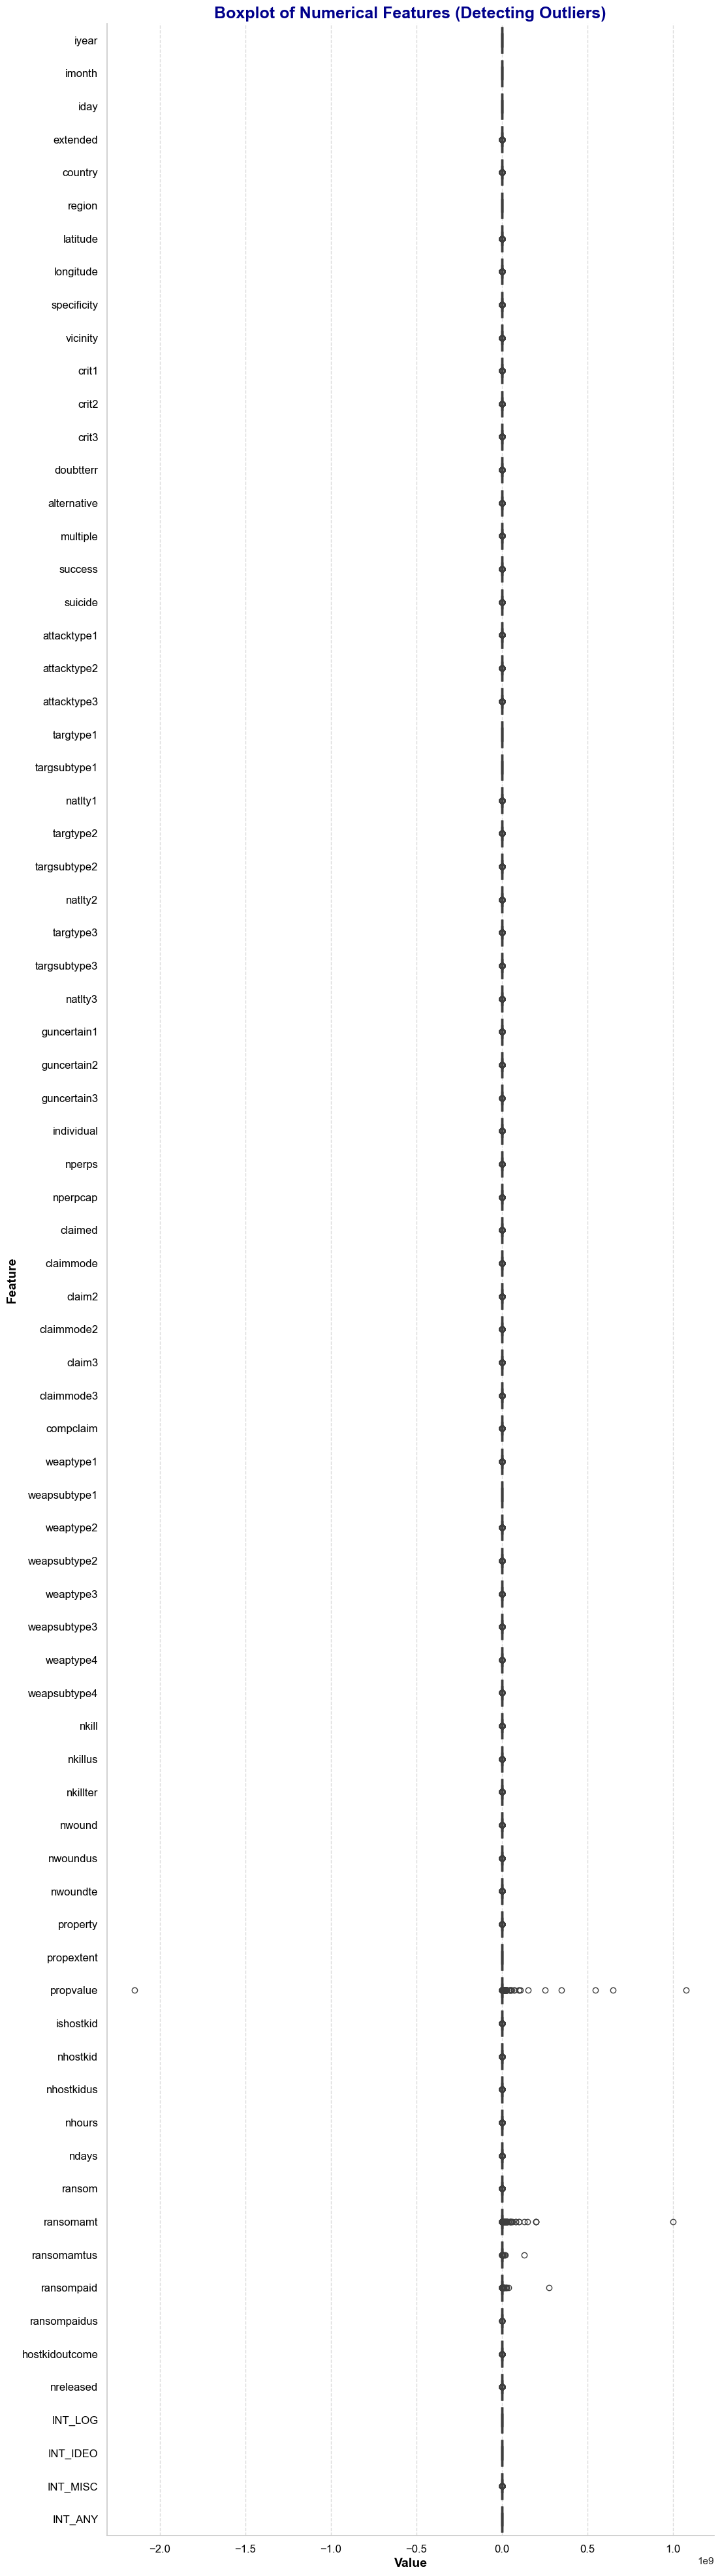

In [7]:
# ----------- Set Seaborn Theme for Better Aesthetics ----------- #
sns.set_theme(style="whitegrid")

# ----------- Select Only Numerical Columns ----------- #
numerical_columns = df.drop(["eventid"], axis=1).select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

# ----------- Create a Vertical Boxplot for Numerical Data ----------- #
plt.figure(figsize=(12, 50))
ax = sns.boxplot(data=df[numerical_columns], orient="h", palette="coolwarm", linewidth=2.5)

# ----------- Customize the Plot ----------- #
plt.title("Boxplot of Numerical Features (Detecting Outliers)", fontsize=18, fontweight="bold", color="darkblue")
plt.ylabel("Feature", fontsize=14, fontweight="bold", color="black")
plt.xlabel("Value", fontsize=14, fontweight="bold", color="black")
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

# ----------- Add Grid for Better Readability ----------- #
plt.grid(axis="x", linestyle="--", alpha=0.7)

# ----------- Enhance Aesthetics ----------- #
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)  # Remove top and right spines for a cleaner look

# ----------- Highlight Outliers in Red for Visibility ----------- #
for artist in ax.artists:
    artist.set_edgecolor("red")
    artist.set_linewidth(2.5)

# ----------- Show the Plot ----------- #
plt.show()

C:\Users\kunmi\AppData\Local\Temp\ipykernel_77448\338584499.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df["propvalue"], orient="h", palette="coolwarm", linewidth=2.5)


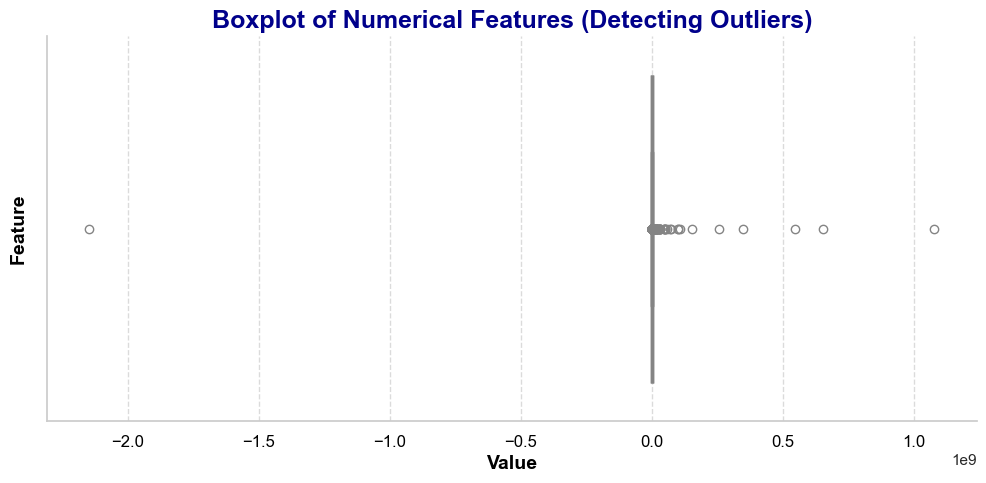

In [8]:
# ----------- Set Seaborn Theme for Better Aesthetics ----------- #
sns.set_theme(style="whitegrid")

# ----------- Select Only Numerical Columns ----------- #
numerical_columns = df.drop(["eventid"], axis=1).select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

# ----------- Create a Vertical Boxplot for Numerical Data ----------- #
plt.figure(figsize=(12, 5))
ax = sns.boxplot(data=df["propvalue"], orient="h", palette="coolwarm", linewidth=2.5)

# ----------- Customize the Plot ----------- #
plt.title("Boxplot of Numerical Features (Detecting Outliers)", fontsize=18, fontweight="bold", color="darkblue")
plt.ylabel("Feature", fontsize=14, fontweight="bold", color="black")
plt.xlabel("Value", fontsize=14, fontweight="bold", color="black")
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

# ----------- Add Grid for Better Readability ----------- #
plt.grid(axis="x", linestyle="--", alpha=0.7)

# ----------- Enhance Aesthetics ----------- #
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)  # Remove top and right spines for a cleaner look

# ----------- Highlight Outliers in Red for Visibility ----------- #
for artist in ax.artists:
    artist.set_edgecolor("red")
    artist.set_linewidth(2.5)

# ----------- Show the Plot ----------- #
plt.show()

In [9]:
pd.set_option('display.max_columns', None)

df[df["propvalue"] < -99]

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,region_txt,provstate,city,latitude,longitude,specificity,vicinity,location,summary,crit1,crit2,crit3,doubtterr,alternative,alternative_txt,multiple,success,suicide,attacktype1,attacktype1_txt,attacktype2,attacktype2_txt,attacktype3,attacktype3_txt,targtype1,targtype1_txt,targsubtype1,targsubtype1_txt,corp1,target1,natlty1,natlty1_txt,targtype2,targtype2_txt,targsubtype2,targsubtype2_txt,corp2,target2,natlty2,natlty2_txt,targtype3,targtype3_txt,targsubtype3,targsubtype3_txt,corp3,target3,natlty3,natlty3_txt,gname,gsubname,gname2,gsubname2,gname3,gsubname3,motive,guncertain1,guncertain2,guncertain3,individual,nperps,nperpcap,claimed,claimmode,claimmode_txt,claim2,claimmode2,claimmode2_txt,claim3,claimmode3,claimmode3_txt,compclaim,weaptype1,weaptype1_txt,weapsubtype1,weapsubtype1_txt,weaptype2,weaptype2_txt,weapsubtype2,weapsubtype2_txt,weaptype3,weaptype3_txt,weapsubtype3,weapsubtype3_txt,weaptype4,weaptype4_txt,weapsubtype4,weapsubtype4_txt,weapdetail,nkill,nkillus,nkillter,nwound,nwoundus,nwoundte,property,propextent,propextent_txt,propvalue,propcomment,ishostkid,nhostkid,nhostkidus,nhours,ndays,divert,kidhijcountry,ransom,ransomamt,ransomamtus,ransompaid,ransompaidus,ransomnote,hostkidoutcome,hostkidoutcome_txt,nreleased,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
50992,199204100007,1992,4,10,Not Applicable,0,Not Applicable,603,United Kingdom,8,Western Europe,England,London,51.504387,-0.140041,1,0,Unknown,No description available,1,1,1,0,0,None,0,1,0,3,Bombing/Explosion,0,None,0,None,14,Private Citizens & Property,75,Village/City/Town/Suburb,Unknown,London Financial District,216,Great Britain,0,None,0,None,None,None,0,None,0,None,0,None,None,None,0,None,Irish Republican Army (IRA),Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,0.0,0.0,0.0,0,0,0,0,0,Unknown,0,0,Unknown,0,0,Unknown,0,6,Explosives,15,Vehicle,0,None,0,None,0,None,0,None,0,None,0,None,Explosive,3,0,0,90,0,0,1,1,Catastrophic (likely >= $1 billion),-2147483648,"Damages: explosion, destroyed historic buildin...",0,0,0,0,0,None,None,0,0,0,0,0,No ransom note,0,Unknown,0,No additional notes,No citation,No citation,No citation,PGIS,1,0,1,1,None


In [10]:
df["propvalue"] = df["propvalue"].astype("int64")  # Convert to 64-bit integer
df["propvalue"] = df["propvalue"].replace(-2147483648, 2147483648)

In [61]:
import pymysql
import pandas as pd

# ----------- Replace NaNs with None ----------- #
df = df.where(pd.notnull(df), None)

# ----------- Connect to MySQL Server (without DB first) ----------- #
connection = pymysql.connect(
    host="localhost",
    user="root",
    password="Yorkshire@123"
)

# ----------- Create Database If Not Exists ----------- #
try:
    with connection.cursor() as cursor:
        cursor.execute("CREATE DATABASE IF NOT EXISTS globalTerrorismDatabase;")
        print("Database Created Or Already Exists.")
finally:
    connection.close()

# ----------- Connect to the Created Database ----------- #
connection = pymysql.connect(
    host="localhost",
    user="root",
    password="Yorkshire@123",
    database="globalTerrorismDatabase"
)

try:
    with connection.cursor() as cursor:
        # ----------- Drop Table If Exists ----------- #
        cursor.execute("DROP TABLE IF EXISTS gtd_data;")

        # ----------- Create GTD Table ----------- #
        cursor.execute("""
        CREATE TABLE gtd_data (
            eventid VARCHAR(20),
            iyear INT,
            imonth INT,
            iday INT,
            approxdate VARCHAR(100),
            extended TINYINT(1),
            resolution TEXT,
            country INT,
            country_txt VARCHAR(100),
            region INT,
            region_txt VARCHAR(100),
            provstate VARCHAR(255),
            city VARCHAR(255),
            latitude FLOAT,
            longitude FLOAT,
            specificity INT,
            vicinity TINYINT(1),
            location TEXT,
            summary TEXT,
            crit1 TINYINT(1),
            crit2 TINYINT(1),
            crit3 TINYINT(1),
            doubtterr TINYINT(1),
            alternative INT,
            alternative_txt VARCHAR(100),
            multiple TINYINT(1),
            success TINYINT(1),
            suicide TINYINT(1),
            attacktype1 INT,
            attacktype1_txt VARCHAR(255),
            attacktype2 INT,
            attacktype2_txt VARCHAR(255),
            attacktype3 INT,
            attacktype3_txt VARCHAR(255),
            targtype1 INT,
            targtype1_txt VARCHAR(255),
            targsubtype1 INT,
            targsubtype1_txt VARCHAR(255),
            corp1 TEXT,
            target1 TEXT,
            natlty1 INT,
            natlty1_txt VARCHAR(100),
            targtype2 INT,
            targtype2_txt VARCHAR(255),
            targsubtype2 INT,
            targsubtype2_txt VARCHAR(255),
            corp2 TEXT,
            target2 TEXT,
            natlty2 INT,
            natlty2_txt VARCHAR(100),
            targtype3 INT,
            targtype3_txt VARCHAR(255),
            targsubtype3 INT,
            targsubtype3_txt VARCHAR(255),
            corp3 TEXT,
            target3 TEXT,
            natlty3 INT,
            natlty3_txt VARCHAR(100),
            gname VARCHAR(255),
            gsubname TEXT,
            gname2 TEXT,
            gsubname2 TEXT,
            gname3 TEXT,
            gsubname3 TEXT,
            motive TEXT,
            guncertain1 TINYINT(1),
            guncertain2 TINYINT(1),
            guncertain3 TINYINT(1),
            individual TINYINT(1),
            nperps INT,
            nperpcap INT,
            claimed INT,
            claimmode INT,
            claimmode_txt VARCHAR(255),
            claim2 INT,
            claimmode2 INT,
            claimmode2_txt VARCHAR(255),
            claim3 INT,
            claimmode3 INT,
            claimmode3_txt VARCHAR(255),
            compclaim INT,
            weaptype1 INT,
            weaptype1_txt VARCHAR(255),
            weapsubtype1 INT,
            weapsubtype1_txt VARCHAR(255),
            weaptype2 INT,
            weaptype2_txt VARCHAR(255),
            weapsubtype2 INT,
            weapsubtype2_txt VARCHAR(255),
            weaptype3 INT,
            weaptype3_txt VARCHAR(255),
            weapsubtype3 INT,
            weapsubtype3_txt VARCHAR(255),
            weaptype4 INT,
            weaptype4_txt VARCHAR(255),
            weapsubtype4 INT,
            weapsubtype4_txt VARCHAR(255),
            weapdetail TEXT,
            nkill INT,
            nkillus INT,
            nkillter INT,
            nwound INT,
            nwoundus INT,
            nwoundte INT,
            property INT,
            propextent INT,
            propextent_txt VARCHAR(255),
            propvalue BIGINT,
            propcomment TEXT,
            ishostkid TINYINT(1),
            nhostkid INT,
            nhostkidus INT,
            nhours INT,
            ndays INT,
            divert TEXT,
            kidhijcountry VARCHAR(255),
            ransom TINYINT(1),
            ransomamt INT,
            ransomamtus INT,
            ransompaid INT,
            ransompaidus INT,
            ransomnote TEXT,
            hostkidoutcome INT,
            hostkidoutcome_txt VARCHAR(255),
            nreleased INT,
            addnotes TEXT,
            scite1 TEXT,
            scite2 TEXT,
            scite3 TEXT,
            dbsource TEXT,
            INT_LOG INT,
            INT_IDEO INT,
            INT_MISC INT,
            INT_ANY INT,
            related TEXT
        );
        """)

        # ----------- Insert Data Dynamically ----------- #
        cols = list(df.columns)
        insert_query = f"""
        INSERT INTO gtd_data ({', '.join(cols)})
        VALUES ({', '.join(['%s'] * len(cols))});
        """
        data = [tuple(row) for row in df.to_numpy()]
        cursor.executemany(insert_query, data)

        connection.commit()
        print("GTD Data Inserted Successfully Into MySQL!")

finally:
    connection.close()

✅ Database created or already exists.
🚀 GTD data inserted successfully into MySQL!
